In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from scipy.stats import linregress
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle

C:\Users\TomAH\anaconda3\envs\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

In [3]:
def select_by_lonlat(ds, lon_target, lat_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return (y_idx, x_idx)


In [ ]:
# Open model and config files

catalog = OceanDataCatalog(catalog_name='noc-model-stac')
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1_annual = catalog.open_dataset(id=catalog.Items[2].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
ds1_5day = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets_annual = {'parent': {'domain': config, 'gridT': ds1_annual}}
dt_global_annual = NEMODataTree.from_datasets(datasets = datasets_annual)
datasets_5day = {'parent': {'domain': config, 'gridT': ds1_5day}}
dt_global_5day = NEMODataTree.from_datasets(datasets = datasets_5day)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_annual = dt_global_annual.clip_grid(grid='/gridT', bbox=bbox)
dt_5day = dt_global_5day.clip_grid(grid='/gridT', bbox=bbox)

# Convert to datasets
ds_annual = (dt_annual['/gridT']).dataset
ds_5day = (dt_5day['/gridT']).dataset

In [4]:
min_region = ds_5day.sel(time_counter = ds_5day['time_counter'].dt.month.isin([2, 3, 4]))
max_region = ds_5day.sel(time_counter = ds_5day['time_counter'].dt.month.isin([8, 9, 10]))
min_temp = ((min_region['tos_con'].groupby('time_counter.year')).min(dim='time_counter')).compute()
print('1')
max_temp = ((max_region['tos_con'].groupby('time_counter.year')).max(dim='time_counter')).compute()

1


In [5]:
min_temp.to_netcdf('min_ts_0.25.nc')
max_temp.to_netcdf('max_ts_0.25.nc')

In [4]:
## Start from here 

years = np.arange(1990, 2025)
salinity = xr.open_dataset('salinity_ts_0.25.nc')['sos_abs']
amplitude = xr.open_dataset('amplitude_ts_0.25.nc')['tos_con']
max_temp = xr.open_dataset('max_ts_0.25.nc')['tos_con']
min_temp = xr.open_dataset('min_ts_0.25.nc')['tos_con']
r_da = (xr.open_dataset('pearsons_0.25.nc'))['correlation']


x index = 221
y index = 258


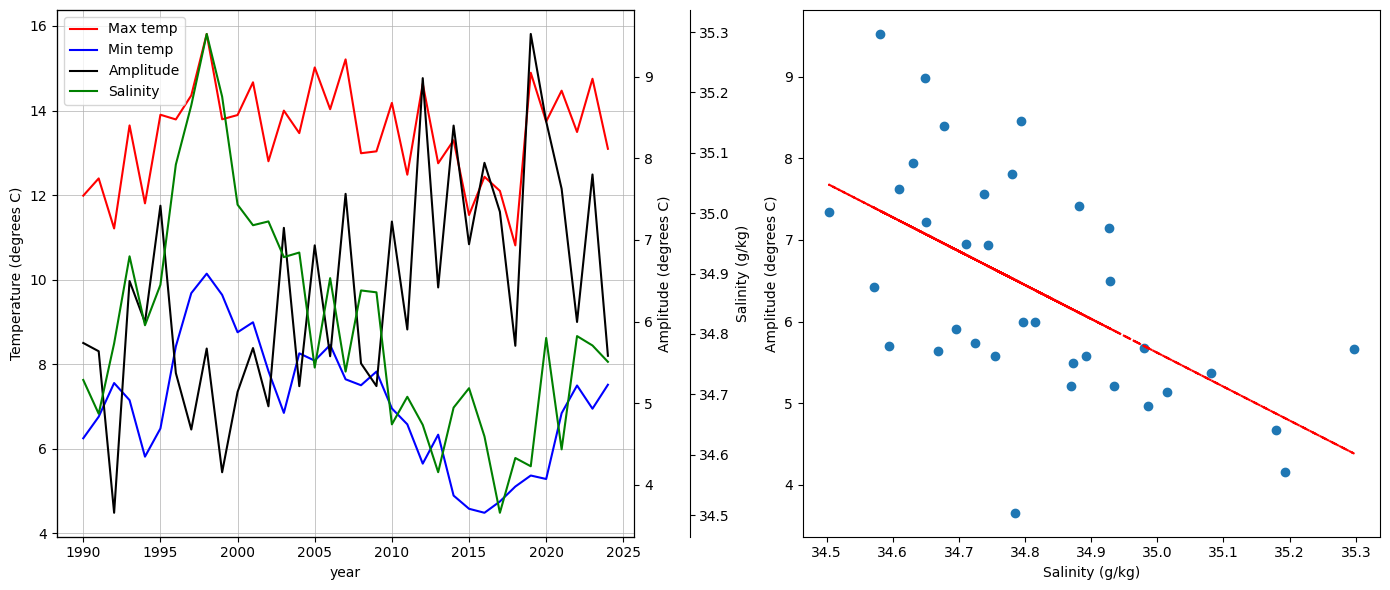

In [19]:
## Consider 30W, 55N 

j_idx, i_idx = select_by_lonlat(amplitude, -30.0, 55.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx).values
salinity_ts = salinity.isel(j=j_idx, i=i_idx).values
max_ts = max_temp.isel(j=j_idx, i=i_idx).values
min_ts = min_temp.isel(j=j_idx, i=i_idx).values

fig, ax = plt.subplots(1, 2, figsize = (14, 6))
ax0 = ax[0]
ax1 = ax0.twinx()
ax2 = ax0.twinx()
ax3 = ax[1]

ax2.spines["right"].set_position(("outward", 40))

l1 = ax0.plot(years, max_ts, color = 'r', label = 'Max temp')
l2 = ax0.plot(years, min_ts, color = 'b', label = 'Min temp')
l3 = ax1.plot(years, amplitude_ts, color = 'k', label = 'Amplitude')
l4 = ax2.plot(years, salinity_ts, color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('year')
ax0.set_ylabel('Temperature (degrees C)')
ax1.set_ylabel('Amplitude (degrees C)')
ax2.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')
ax0.grid(True, which='both', linewidth=0.5)

ax3.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax3.plot(salinity_ts ,p(salinity_ts),color = 'r', linestyle = '--')
ax3.set_xlabel('Salinity (g/kg)')
ax3.set_ylabel('Amplitude (degrees C)')

plt.tight_layout()
plt.show()

x index = 101
y index = 187


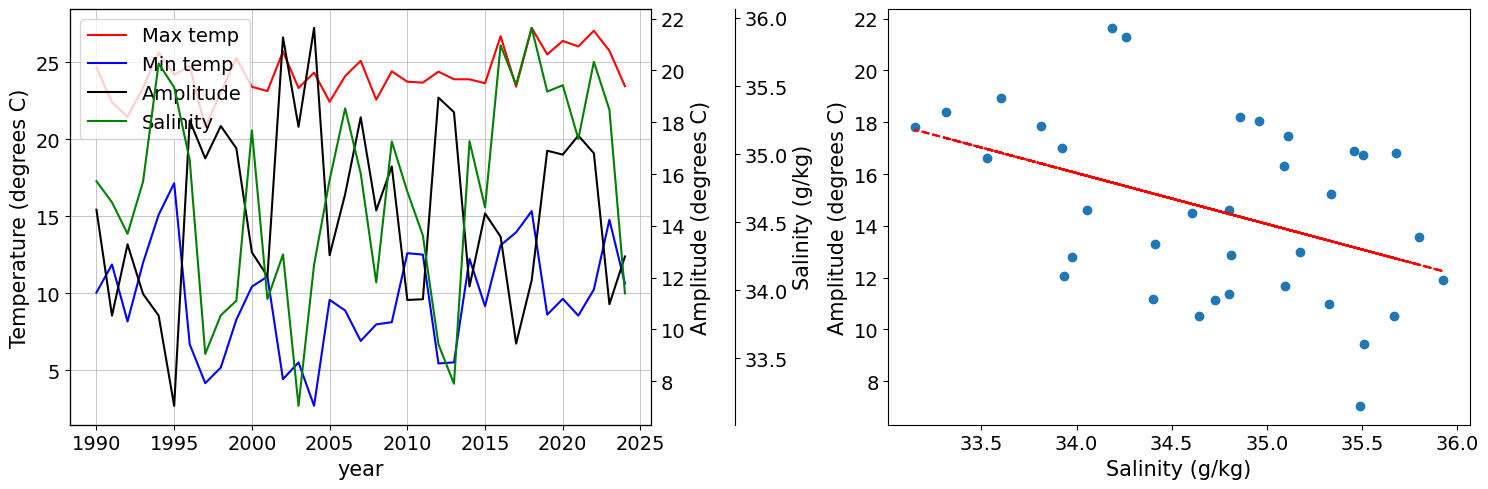

In [14]:
## Consider 60W, 42N 

j_idx, i_idx = select_by_lonlat(amplitude, -60.0, 42.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx).values
salinity_ts = salinity.isel(j=j_idx, i=i_idx).values
max_ts = max_temp.isel(j=j_idx, i=i_idx).values
min_ts = min_temp.isel(j=j_idx, i=i_idx).values

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ax0 = ax[0]
ax1 = ax0.twinx()
ax2 = ax0.twinx()
ax3 = ax[1]

ax2.spines["right"].set_position(("outward", 60))

l1 = ax0.plot(years, max_ts, color = 'r', label = 'Max temp')
l2 = ax0.plot(years, min_ts, color = 'b', label = 'Min temp')
l3 = ax1.plot(years, amplitude_ts, color = 'k', label = 'Amplitude')
l4 = ax2.plot(years, salinity_ts, color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('year')
ax0.set_ylabel('Temperature (degrees C)')
ax1.set_ylabel('Amplitude (degrees C)')
ax2.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')
ax0.grid(True, which='both', linewidth=0.5)

ax3.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax3.plot(salinity_ts ,p(salinity_ts),color = 'r', linestyle = '--')
ax3.set_xlabel('Salinity (g/kg)')
ax3.set_ylabel('Amplitude (degrees C)')
    
plt.tight_layout()
plt.show()

x index = 148
y index = 377


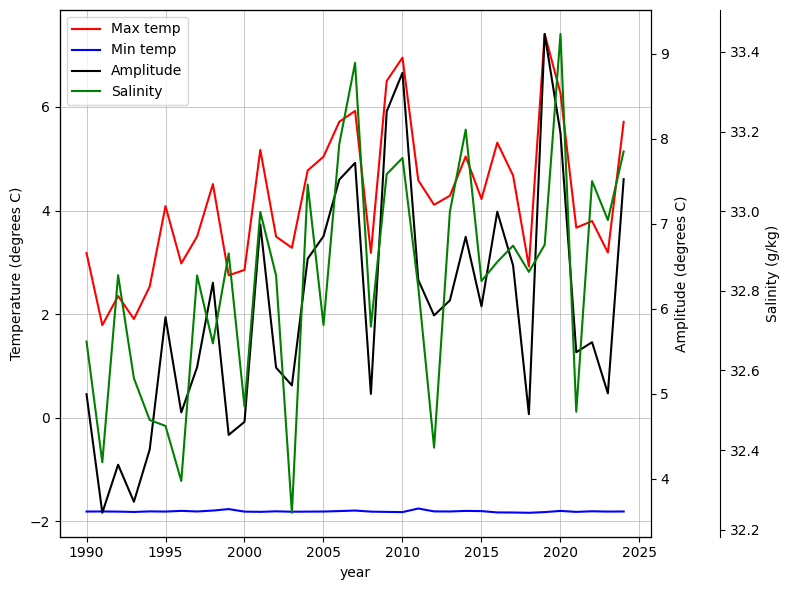

In [11]:
## Consider 58W, 70N 

j_idx, i_idx = select_by_lonlat(amplitude, -58.0, 70.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx).values
salinity_ts = salinity.isel(j=j_idx, i=i_idx).values
max_ts = max_temp.isel(j=j_idx, i=i_idx).values
min_ts = min_temp.isel(j=j_idx, i=i_idx).values

fig, ax = plt.subplots(figsize = (8, 6))
ax0 = ax
ax1 = ax0.twinx()
ax2 = ax0.twinx()
ax2.spines["right"].set_position(("outward", 50))

l1 = ax0.plot(years, max_ts, color = 'r', label = 'Max temp')
l2 = ax0.plot(years, min_ts, color = 'b', label = 'Min temp')
l3 = ax1.plot(years, amplitude_ts, color = 'k', label = 'Amplitude')
l4 = ax2.plot(years, salinity_ts, color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('year')
ax0.set_ylabel('Temperature (degrees C)')
ax1.set_ylabel('Amplitude (degrees C)')
ax2.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'best')
ax0.grid(True, which='both', linewidth=0.5)

plt.tight_layout()
plt.show()

x index = 160
y index = 126


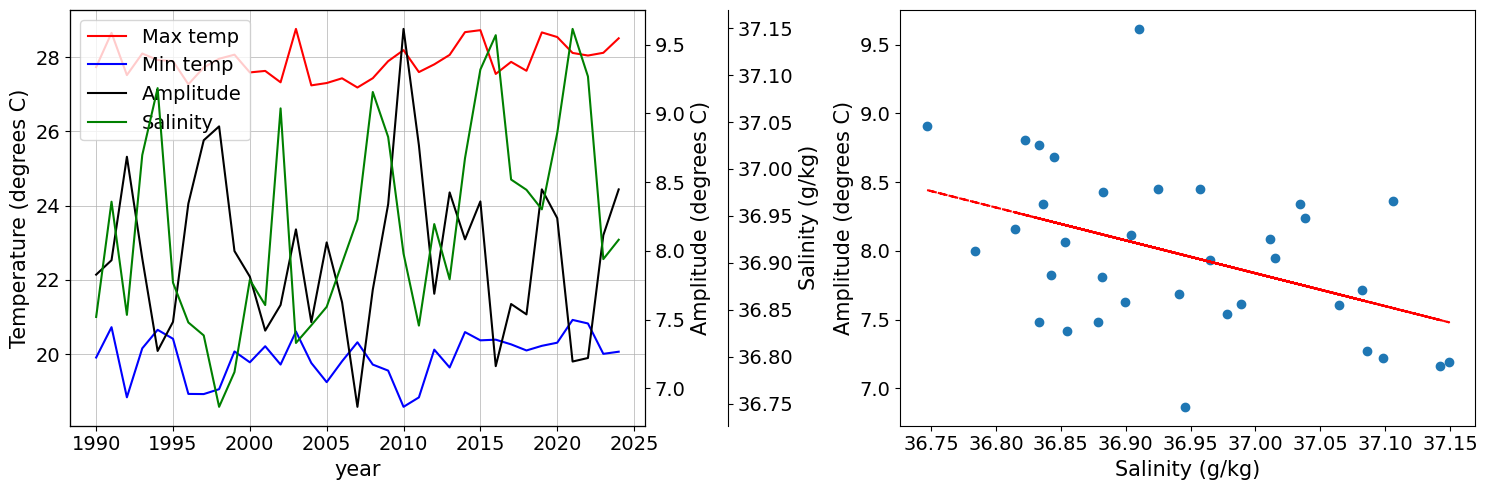

In [16]:
## Consider 45W, 30N 

j_idx, i_idx = select_by_lonlat(amplitude, -45.0, 30.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx).values
salinity_ts = salinity.isel(j=j_idx, i=i_idx).values
max_ts = max_temp.isel(j=j_idx, i=i_idx).values
min_ts = min_temp.isel(j=j_idx, i=i_idx).values

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ax0 = ax[0]
ax1 = ax0.twinx()
ax2 = ax0.twinx()
ax3 = ax[1]
ax2.spines["right"].set_position(("outward", 60))

l1 = ax0.plot(years, max_ts, color = 'r', label = 'Max temp')
l2 = ax0.plot(years, min_ts, color = 'b', label = 'Min temp')
l3 = ax1.plot(years, amplitude_ts, color = 'k', label = 'Amplitude')
l4 = ax2.plot(years, salinity_ts, color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('year')
ax0.set_ylabel('Temperature (degrees C)')
ax1.set_ylabel('Amplitude (degrees C)')
ax2.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')
ax0.grid(True, which='both', linewidth=0.5)

ax3.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax3.plot(salinity_ts ,p(salinity_ts),color = 'r', linestyle = '--')
ax3.set_xlabel('Salinity (g/kg)')
ax3.set_ylabel('Amplitude (degrees C)')

plt.tight_layout()
plt.show()

x index = 260
y index = 99


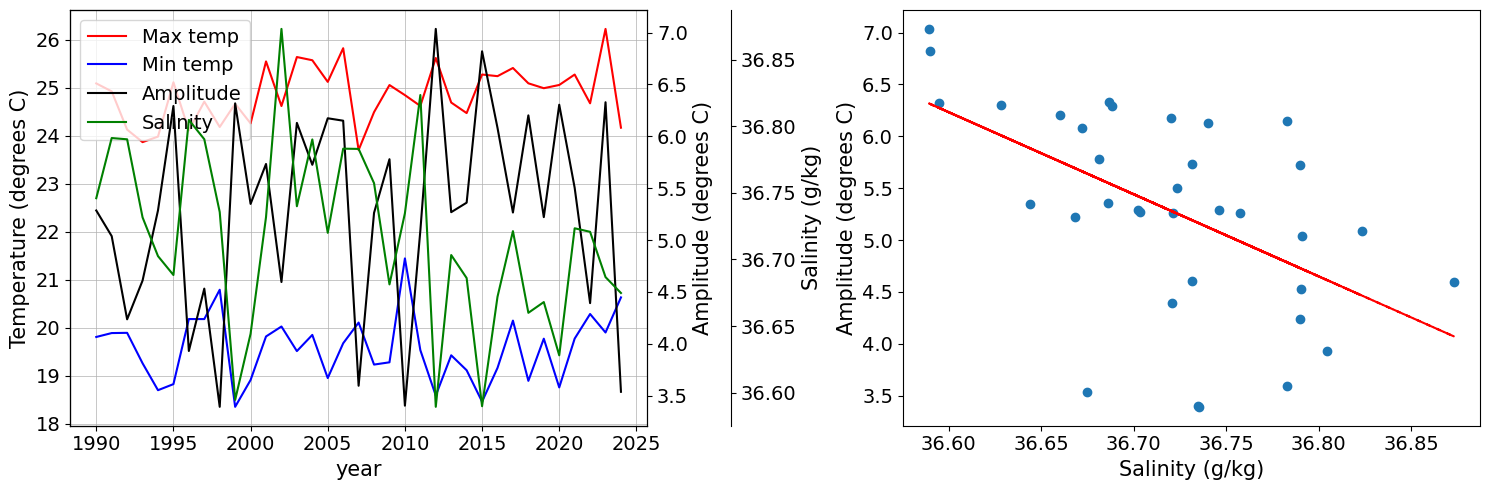

In [18]:
## Consider 20W, 24N 

j_idx, i_idx = select_by_lonlat(amplitude, -20.0, 24.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx).values
salinity_ts = salinity.isel(j=j_idx, i=i_idx).values
max_ts = max_temp.isel(j=j_idx, i=i_idx).values
min_ts = min_temp.isel(j=j_idx, i=i_idx).values

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ax0 = ax[0]
ax1 = ax0.twinx()
ax2 = ax0.twinx()
ax3 = ax[1]
ax2.spines["right"].set_position(("outward", 60))

l1 = ax0.plot(years, max_ts, color = 'r', label = 'Max temp')
l2 = ax0.plot(years, min_ts, color = 'b', label = 'Min temp')
l3 = ax1.plot(years, amplitude_ts, color = 'k', label = 'Amplitude')
l4 = ax2.plot(years, salinity_ts, color = 'g', label = 'Salinity')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]

ax0.set_xlabel('year')
ax0.set_ylabel('Temperature (degrees C)')
ax1.set_ylabel('Amplitude (degrees C)')
ax2.set_ylabel('Salinity (g/kg)')
ax0.legend(lines, labels, loc = 'upper left')
ax0.grid(True, which='both', linewidth=0.5)

ax3.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax3.plot(salinity_ts ,p(salinity_ts),color = 'r', linestyle = '--')
ax3.set_xlabel('Salinity (g/kg)')
ax3.set_ylabel('Amplitude (degrees C)')

plt.tight_layout()
plt.show()